# Exponential Smoothing (ETS)

This notebook demonstrates the **ETS** forecaster in the `aeon` toolkit. ETS stands for **E**rror, **T**rend, **S**easonality: the family of exponential-smoothing models written in state-space form. Where [CES](ces.ipynb) hides trend and seasonality inside a single complex smoothing parameter, ETS does the opposite — it names those components **explicitly** and you (or `AutoETS`) choose a type for each.

ETS is one of the most widely used statistical forecasters and a standard benchmark. The state-space formulation used here follows Hyndman and Athanasopoulos.

> R. J. Hyndman & G. Athanasopoulos (2021). *Forecasting: Principles and Practice* (3rd ed.), OTexts. https://otexts.com/fpp3/

*See also the [CES](ces.ipynb), [Theta](theta.ipynb) and [DOTM](dotm.ipynb) notebooks; section 6 below relates all of them.*


## 1. How the ETS algorithm works

ETS describes a series with up to three components that are each updated by exponential smoothing:

- a **level** $\ell_t$, smoothed with parameter $\alpha$,
- a **trend** $b_t$, smoothed with $\beta$ (optionally **damped** by $\phi \in (0, 1]$),
- a **seasonal** component $s_t$ of period $m$, smoothed with $\gamma$.

For the additive-trend, non-seasonal model the recursions are

$$\ell_t = \alpha y_t + (1-\alpha)(\ell_{t-1} + \phi b_{t-1}), \qquad b_t = \beta(\ell_t - \ell_{t-1}) + (1-\beta)\,\phi\, b_{t-1},$$

and the $h$-step forecast adds a (damped) trend to the level:

$$\hat{y}_{t+h} = \ell_t + (\phi + \phi^2 + \dots + \phi^h)\, b_t.$$

**The ETS taxonomy.** Each component has a *type*, which is where the family comes from:

- **Error**: additive (A) or multiplicative (M),
- **Trend**: none (N), additive (A), or multiplicative (M),
- **Seasonality**: none (N), additive (A), or multiplicative (M).

A model is written `ETS(E,T,S)` — e.g. `ETS(A,N,N)` is simple exponential smoothing, `ETS(A,A,N)` is Holt's linear trend, and `ETS(M,A,M)` is the classic multiplicative airline model. The smoothing parameters $\alpha, \beta, \gamma, \phi$ are **estimated** by maximum likelihood (here via a Nelder-Mead optimiser minimising AIC); you only choose the component *types*.


## 2. Parameters and their effects

`ETS` takes the component types, not the smoothing parameters (those are fitted):

- **`error_type`** (default `'additive'`): `'additive'` or `'multiplicative'`. Multiplicative error requires strictly positive data.
- **`trend_type`** (default `None`): `None`, `'additive'`, or `'multiplicative'`. An additive trend here is automatically **damped** by an estimated $\phi$.
- **`seasonality_type`** (default `None`): `None`, `'additive'`, or `'multiplicative'`.
- **`seasonal_period`** (default `1`): the season length $m$; needs to be set (e.g. `12`) for any seasonal model.
- **`iterations`** (default `200`): Nelder-Mead iteration budget.

Integer codes are also accepted (`additive=1`, `multiplicative=2`, `None=0`), but the strings are clearer. The fitted smoothing parameters are exposed afterwards as `alpha_`, `beta_`, `gamma_`, `phi_`, and the fitted states as `level_`, `trend_`, `seasonality_`.

Choosing types by hand is fiddly, so in practice you usually let **`AutoETS`** search the taxonomy for you (section 5).


## 3. Forecasting with ETS

### Imports


In [1]:
import matplotlib.pyplot as plt
import numpy as np

from aeon.datasets import load_airline
from aeon.forecasting.stats import ETS, AutoETS

### Example: fit, `forecast` and `iterative_forecast`

We use the same trending series as the [CES notebook](ces.ipynb) and hold out the last 12 points. Here we ask for an additive trend explicitly with `ETS(A,A,N)` (Holt's method); the smoothing parameters are estimated.


One-step-ahead forecast: 33.196


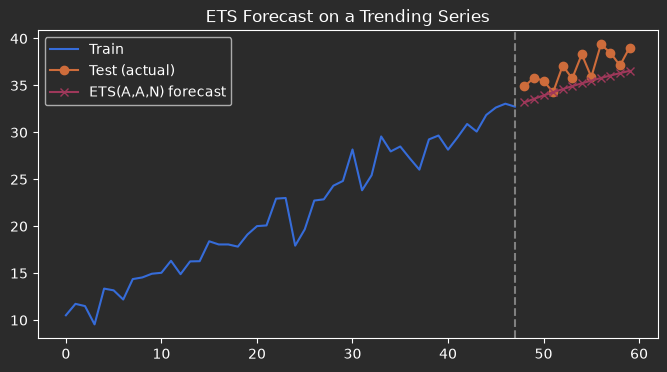

Test MSE over 12 steps: 4.371


In [2]:
# A trending series + noise (same as the CES notebook)
rng = np.random.default_rng(1)
n_points = 60
time = np.arange(n_points)
y = 10 + 0.5 * time + rng.normal(scale=1.5, size=n_points)

y_train, y_test = y[:-12], y[-12:]

forecaster = ETS(error_type="additive", trend_type="additive", seasonality_type=None)
forecaster.fit(y_train)
print(f"One-step-ahead forecast: {forecaster.forecast(y_train):.3f}")

y_preds = forecaster.iterative_forecast(y_train, prediction_horizon=len(y_test))

test_time = np.arange(len(y_train), len(y))
plt.figure(figsize=(8, 4))
plt.plot(np.arange(len(y_train)), y_train, label="Train")
plt.plot(test_time, y_test, marker="o", label="Test (actual)")
plt.plot(test_time, y_preds, marker="x", label="ETS(A,A,N) forecast")
plt.axvline(x=len(y_train) - 1, linestyle="--", color="grey")
plt.legend()
plt.title("ETS Forecast on a Trending Series")
plt.show()

print(f"Test MSE over {len(y_test)} steps: " f"{np.mean((y_test - y_preds) ** 2):.3f}")

The fitted components and smoothing parameters are stored as attributes. Note that even though we did not ask for damping, the additive trend is fitted with a damping factor $\phi < 1$:


In [3]:
print(f"alpha_ (level)  : {forecaster.alpha_:.4f}")
print(f"beta_  (trend)  : {forecaster.beta_:.4f}")
print(f"phi_   (damping): {forecaster.phi_:.4f}")
print(f"level_          : {forecaster.level_:.4f}")
print(f"trend_          : {forecaster.trend_:.4f}")

alpha_ (level)  : 0.3225
beta_  (trend)  : 0.0507
phi_   (damping): 0.9573
level_          : 32.8028
trend_          : 0.4104


## 4. Worked example: the forecast is level plus a damped trend

ETS forecasts are transparent. For `ETS(A,A,N)` every step beyond the data is the final level plus the damped trend accumulated over the horizon,

$$\hat{y}_{t+h} = \ell_t + \Big(\sum_{k=1}^{h} \phi^{k}\Big)\, b_t.$$

With $\phi = 1$ the sum is just $h$ (an undamped straight line); with $\phi < 1$ the sum converges, so the forecast **flattens out** at long horizons instead of extrapolating forever. We can reproduce `iterative_forecast` exactly from `level_`, `trend_` and `phi_`:


In [4]:
lvl, tr, phi = forecaster.level_, forecaster.trend_, forecaster.phi_

manual = []
for h in range(1, len(y_test) + 1):
    phi_h = h if phi == 1 else phi * (1 - phi**h) / (1 - phi)  # phi + ... + phi^h
    manual.append(lvl + phi_h * tr)
manual = np.array(manual)

print("Max abs diff vs iterative_forecast:", np.max(np.abs(manual - y_preds)))
print(
    f"phi_ = {phi:.4f}: the trend contribution saturates at "
    f"{tr * phi / (1 - phi):.2f} as the horizon grows"
)

Max abs diff vs iterative_forecast: 7.105427357601002e-15
phi_ = 0.9573: the trend contribution saturates at 9.19 as the horizon grows


This damping is the key behavioural knob of a trended ETS: it is why an ETS trend forecast bends towards a horizontal asymptote rather than running away. (Compare with [DOTM](dotm.ipynb), whose trend line is re-estimated dynamically instead of damped.)


## 5. Seasonal ETS and AutoETS

Series like airline passengers are seasonal, and hand-picking the `(E,T,S)` types is
a source of error and potential bias (through manual overfitting). **`AutoETS`** fits
every admissible combination and keeps the one with the lowest AIC. You can either give
 it the `seasonal_period` or let it estimate one.


AutoETS selected ETS(M,N,M) with m=12
AutoETS test MSE: 7975.1


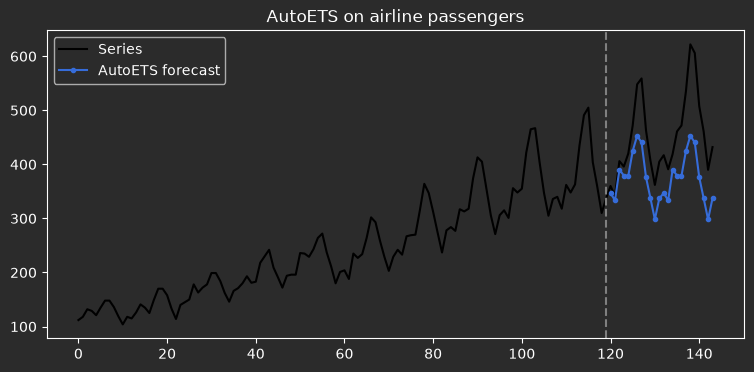

In [5]:
y_air = load_airline().squeeze()
y_train, y_test = y_air[:-24], y_air[-24:]

auto = AutoETS(seasonal_period=12)
auto.fit(y_train)
names = {0: "N", 1: "A", 2: "M"}
print(
    "AutoETS selected ETS("
    f"{names[auto.error_type_]},{names[auto.trend_type_]},"
    f"{names[auto.seasonality_type_]}) with m={auto.seasonal_period_}"
)

auto_preds = auto.iterative_forecast(y_train, prediction_horizon=24)
print(f"AutoETS test MSE: {np.mean((y_test - auto_preds) ** 2):.1f}")

time = np.arange(len(y_air))
plt.figure(figsize=(9, 4))
plt.plot(time, y_air, label="Series", color="black")
plt.axvline(x=len(y_train) - 1, linestyle="--", color="grey")
fut = np.arange(len(y_train), len(y_air))
plt.plot(fut, auto_preds, marker=".", label="AutoETS forecast")
plt.legend()
plt.title("AutoETS on airline passengers")
plt.show()

As in the [CES notebook](ces.ipynb), it is worth being explicit about what `AutoETS` optimises. It minimises **AIC** on the training data, which rewards in-sample likelihood while penalising the number of parameters. That is not identical to minimising test error: on this airline split the lowest-AIC model uses a multiplicative season but **no explicit trend**, so its long forecast tracks the seasonal shape around a slowly drifting level and under-projects the upward trend somewhat. A model with an additive season can score a lower test MSE here while having a worse AIC. IC-based selection trades a little test accuracy for protection against overfitting — usually a sensible default, but good to understand.


## 6. How ETS, CES, Theta and DOTM relate

These four notebooks cover one extended family. It helps to see them side by side:

| Method | How trend/season are handled | Model choice |
|---|---|---|
| **[Theta](theta.ipynb)** | fixed linear trend + SES level | none (fixed) |
| **[DOTM](dotm.ipynb)** | trend line re-estimated *dynamically*; optional seasonal decomposition | mostly automatic |
| **ETS** | trend/season named **explicitly** as additive/multiplicative/none, with damping | pick `(E,T,S)` types (or `AutoETS`) |
| **[CES](ces.ipynb)** | trend/season absorbed into a **complex** smoothing parameter | pick seasonal variant (or `AutoCES`) |

The throughline is exponential smoothing of a level. The methods differ in how they add longer-range structure: Theta bolts on a fixed trend, DOTM makes that trend adaptive, ETS enumerates explicit component types and selects among them by AIC, and CES replaces the explicit components with a single complex parameter whose eigenvalues do the same job implicitly. `ETS(A,N,N)` (simple exponential smoothing) is the common ancestor that all of them reduce to when there is no trend or season to model.


## 7. Summary

- **ETS** models a series as exponentially-smoothed **level**, **trend** (optionally damped) and **seasonal** components, each typed as additive, multiplicative or none — the `ETS(E,T,S)` taxonomy.
- You choose the component *types*; the smoothing parameters $\alpha, \beta, \gamma, \phi$ are estimated by minimising AIC.
- The forecast is transparent: for `ETS(A,A,N)` it is the level plus a damped-trend sum that flattens at long horizons.
- **`AutoETS`** searches the taxonomy and selects by information criterion — convenient, but IC-optimal is not the same as test-optimal.
- ETS is the explicit-component counterpart to **[CES](ces.ipynb)**; see section 6 for how the whole family fits together.

### Reference

R. J. Hyndman & G. Athanasopoulos (2021). *Forecasting: Principles and Practice* (3rd ed.), OTexts.
